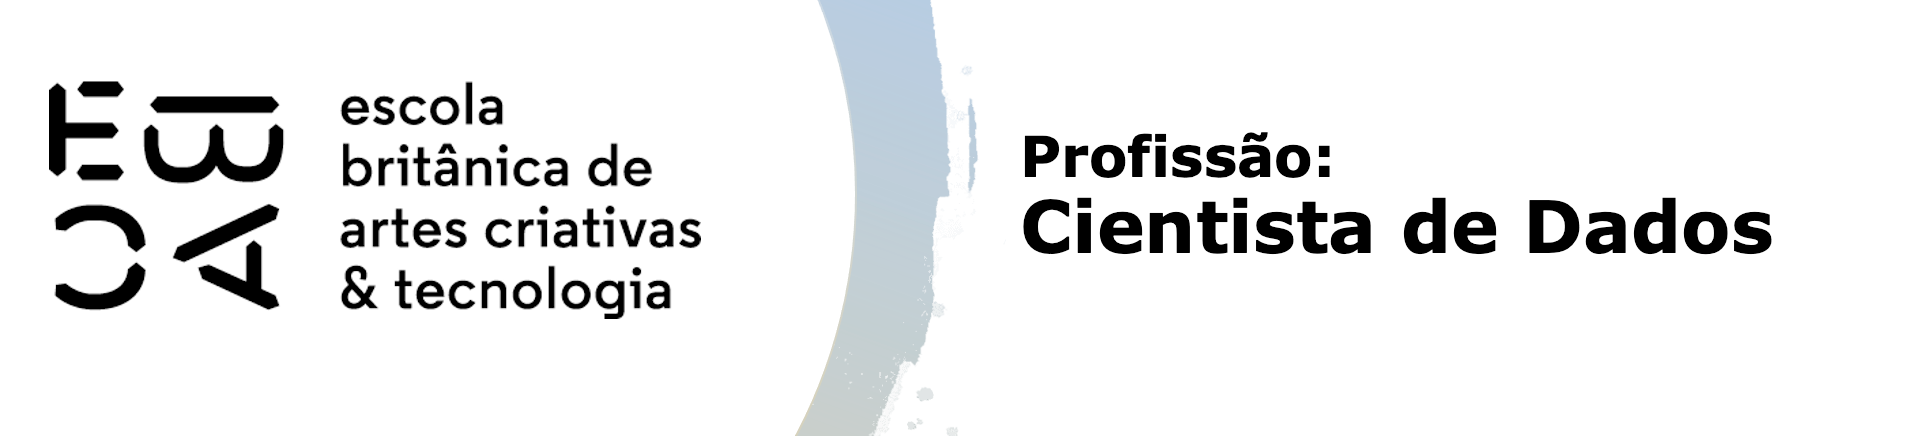

# Tarefa I

Neste projeto, estamos construindo um credit scoring para cartão de crédito, em um desenho amostral com 15 safras, e utilizando 12 meses de performance.

Carregue a base de dados ```credit_scoring.ftr```.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA

# Carregar a base
df = pd.read_feather('credit_scoring.ftr')

print('Dimensão da base:', df.shape)
df.head()

Dimensão da base: (750000, 15)


,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


## Amostragem

Separe os três últimos meses como safras de validação *out of time* (oot).

Variáveis:<br>
Considere que a variável ```data_ref``` não é uma variável explicativa, é somente uma variável indicadora da safra, e não deve ser utilizada na modelagem. A variávei ```index``` é um identificador do cliente, e também não deve ser utilizada como covariável (variável explicativa). As restantes podem ser utilizadas para prever a inadimplência, incluindo a renda.


In [2]:
# Garantir que a data esteja no formato correto
df['data_ref'] = pd.to_datetime(df['data_ref'])

# Identificar as safras em ordem
safras = sorted(df['data_ref'].unique())

print('Quantidade de safras:', len(safras))
print('Primeira safra:', safras[0])
print('Última safra:', safras[-1])
print('Safras OOT:', safras[-3:])

# Separar desenvolvimento e out of time
df_oot = df[df['data_ref'].isin(safras[-3:])].copy()
df_dev = df[~df['data_ref'].isin(safras[-3:])].copy()

print('Base de desenvolvimento:', df_dev.shape)
print('Base out of time:', df_oot.shape)

df_dev.head()

Quantidade de safras: 15
Primeira safra: 2015-01-01 00:00:00
Última safra: 2016-03-01 00:00:00
Safras OOT: [Timestamp('2016-01-01 00:00:00'), Timestamp('2016-02-01 00:00:00'), Timestamp('2016-03-01 00:00:00')]
Base de desenvolvimento: (600000, 15)
Base out of time: (150000, 15)


,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


In [3]:
# Separar variáveis explicativas e variável resposta
variaveis_remover = ['data_ref', 'index', 'mau']

X_dev = df_dev.drop(columns=variaveis_remover)
y_dev = df_dev['mau'].astype(int)

X_oot = df_oot.drop(columns=variaveis_remover)
y_oot = df_oot['mau'].astype(int)

# Separar treino e teste dentro da base de desenvolvimento
X_train, X_test, y_train, y_test = train_test_split(
    X_dev,
    y_dev,
    test_size=0.30,
    random_state=42,
    stratify=y_dev
)

print('Treino:', X_train.shape)
print('Teste desenvolvimento:', X_test.shape)
print('Out of time:', X_oot.shape)

X_train.head()

Treino: (420000, 12)
Teste desenvolvimento: (180000, 12)
Out of time: (150000, 12)


,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda
293455,F,N,S,0,Pensionista,Médio,Solteiro,Casa,65,NaN,1.0,80943.22
211337,F,N,S,0,Assalariado,Médio,Solteiro,Casa,49,8.367123,1.0,19908.65
35205,M,S,N,1,Servidor público,Superior completo,Casado,Casa,39,7.501370,3.0,3355.62
372715,F,N,S,1,Empresário,Superior completo,Casado,Casa,26,7.972603,3.0,12512.27
185068,F,N,S,0,Assalariado,Médio,Solteiro,Casa,45,26.249315,1.0,72958.63


## Descritiva básica univariada

- Descreva a base quanto ao número de linhas, número de linhas para cada mês em ```data_ref```.
- Faça uma descritiva básica univariada de cada variável. Considere as naturezas diferentes: qualitativas e quantitativas.

In [4]:
# Quantidade de linhas e colunas
print('Quantidade de linhas e colunas:', df.shape)

# Quantidade de linhas por safra
qtd_por_safra = (
    df.groupby('data_ref')
      .size()
      .reset_index(name='quantidade')
      .sort_values('data_ref')
)

print('Quantidade de safras:', qtd_por_safra.shape[0])
qtd_por_safra.head(20)

Quantidade de linhas e colunas: (750000, 15)
Quantidade de safras: 15


,data_ref,quantidade
0,2015-01-01,50000
1,2015-02-01,50000
2,2015-03-01,50000
3,2015-04-01,50000
4,2015-05-01,50000
5,2015-06-01,50000
6,2015-07-01,50000
7,2015-08-01,50000
8,2015-09-01,50000
9,2015-10-01,50000


In [5]:
# Separar variáveis por tipo
variaveis_numericas = X_dev.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns.tolist()
variaveis_categoricas = X_dev.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Variáveis numéricas:', variaveis_numericas)
print('Variáveis categóricas:', variaveis_categoricas)

Variáveis numéricas: ['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']
Variáveis categóricas: ['sexo', 'posse_de_veiculo', 'posse_de_imovel', 'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']


In [6]:
# Descritiva das variáveis numéricas
descritiva_numericas = X_dev[variaveis_numericas].describe().T

print('Total de variáveis numéricas:', len(variaveis_numericas))
descritiva_numericas.head(20)

Total de variáveis numéricas: 5


,count,mean,std,min,25%,50%,75%,max
qtd_filhos,600000.0,0.433210,0.739869,0.000000,0.000000,0.000000,1.000000,1.400000e+01
idade,600000.0,43.798530,11.230659,22.000000,34.000000,43.000000,53.000000,6.800000e+01
tempo_emprego,499125.0,7.747992,6.688576,0.117808,3.049315,6.046575,10.180822,4.290685e+01
qt_pessoas_residencia,600000.0,2.212122,0.903757,1.000000,2.000000,2.000000,3.000000,1.500000e+01
renda,600000.0,27222.844732,87377.875997,161.860000,4670.600000,9887.580000,21628.870000,4.083986e+06


In [7]:
# Descritiva das variáveis categóricas
lista_categoricas = []

for coluna in variaveis_categoricas:
    temp = (
        X_dev[coluna]
        .value_counts(dropna=False)
        .reset_index()
    )
    temp.columns = ['categoria', 'quantidade']
    temp['variavel'] = coluna
    temp['percentual'] = temp['quantidade'] / len(X_dev)
    lista_categoricas.append(temp[['variavel', 'categoria', 'quantidade', 'percentual']])

descritiva_categoricas = pd.concat(lista_categoricas, ignore_index=True)

print('Total de variáveis categóricas:', len(variaveis_categoricas))
descritiva_categoricas.head(30)

Total de variáveis categóricas: 7


,variavel,categoria,quantidade,percentual
0,sexo,F,403805,0.673008
1,sexo,M,196195,0.326992
2,posse_de_veiculo,N,366293,0.610488
3,posse_de_veiculo,S,233707,0.389512
4,posse_de_imovel,S,403054,0.671757
5,posse_de_imovel,N,196946,0.328243
6,tipo_renda,Assalariado,308460,0.514100
7,tipo_renda,Empresário,138141,0.230235
8,tipo_renda,Pensionista,101127,0.168545
9,tipo_renda,Servidor público,51981,0.086635


In [8]:
# Taxa geral de inadimplência
taxa_mau = y_dev.mean()

print('Taxa geral de mau na base de desenvolvimento:', round(taxa_mau, 4))

df_dev['mau'].value_counts(normalize=True).to_frame('proporcao')

Taxa geral de mau na base de desenvolvimento: 0.0611


,proporcao
mau,
False,0.938928
True,0.061072


## Descritiva bivariada

Faça uma análise descritiva bivariada de cada variável

In [9]:
# Bivariada para variáveis categóricas
lista_bivariada_cat = []

for coluna in variaveis_categoricas:
    temp = (
        df_dev
        .groupby(coluna, dropna=False)
        .agg(
            quantidade=('mau', 'size'),
            taxa_mau=('mau', 'mean')
        )
        .reset_index()
    )
    temp['variavel'] = coluna
    temp = temp.rename(columns={coluna: 'categoria'})
    lista_bivariada_cat.append(temp[['variavel', 'categoria', 'quantidade', 'taxa_mau']])

bivariada_cat = pd.concat(lista_bivariada_cat, ignore_index=True)

print('Bivariada categórica criada.')
bivariada_cat.head(30)

Bivariada categórica criada.


,variavel,categoria,quantidade,taxa_mau
0,sexo,F,403805,0.063117
1,sexo,M,196195,0.056862
2,posse_de_veiculo,N,366293,0.061467
3,posse_de_veiculo,S,233707,0.060452
4,posse_de_imovel,N,196946,0.069263
5,posse_de_imovel,S,403054,0.057069
6,tipo_renda,Assalariado,308460,0.063525
7,tipo_renda,Bolsista,291,0.041237
8,tipo_renda,Empresário,138141,0.059403
9,tipo_renda,Pensionista,101127,0.064276


In [10]:
# Bivariada para variáveis numéricas usando faixas por quantis
lista_bivariada_num = []

for coluna in variaveis_numericas:
    temp = df_dev[[coluna, 'mau']].copy()

    try:
        temp['faixa'] = pd.qcut(temp[coluna], q=10, duplicates='drop')
    except ValueError:
        temp['faixa'] = temp[coluna]

    resumo = (
        temp
        .groupby('faixa', observed=False)
        .agg(
            quantidade=('mau', 'size'),
            media_variavel=(coluna, 'mean'),
            taxa_mau=('mau', 'mean')
        )
        .reset_index()
    )
    resumo['variavel'] = coluna
    lista_bivariada_num.append(resumo[['variavel', 'faixa', 'quantidade', 'media_variavel', 'taxa_mau']])

bivariada_num = pd.concat(lista_bivariada_num, ignore_index=True)

print('Bivariada numérica criada.')
bivariada_num.head(30)

Bivariada numérica criada.


,variavel,faixa,quantidade,media_variavel,taxa_mau
0,qtd_filhos,"(-0.001, 1.0]",536353,0.228340,0.060924
1,qtd_filhos,"(1.0, 2.0]",55603,2.000000,0.061525
2,qtd_filhos,"(2.0, 14.0]",8044,3.263178,0.067752
3,idade,"(21.999, 29.0]",66984,27.138570,0.079959
4,idade,"(29.0, 33.0]",68151,31.528884,0.068304
5,idade,"(33.0, 36.0]",49089,34.968751,0.062723
6,idade,"(36.0, 40.0]",74613,38.519708,0.061973
7,idade,"(40.0, 43.0]",52116,41.998791,0.054724
8,idade,"(43.0, 47.0]",62810,45.511447,0.057602
9,idade,"(47.0, 51.0]",58138,49.533936,0.050157


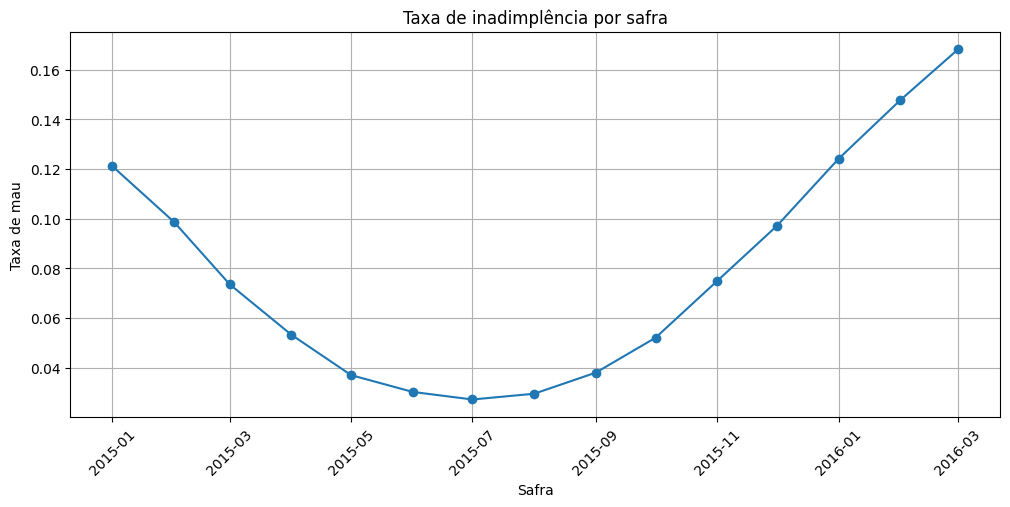

Taxa por safra:


,data_ref,taxa_mau,quantidade
0,2015-01-01,0.12114,50000
1,2015-02-01,0.09868,50000
2,2015-03-01,0.07356,50000
3,2015-04-01,0.05326,50000
4,2015-05-01,0.03702,50000
5,2015-06-01,0.03026,50000
6,2015-07-01,0.02722,50000
7,2015-08-01,0.02954,50000
8,2015-09-01,0.03804,50000
9,2015-10-01,0.05208,50000


In [11]:
# Gráfico simples da taxa de mau por safra
taxa_safra = (
    df.groupby('data_ref')
      .agg(taxa_mau=('mau', 'mean'), quantidade=('mau', 'size'))
      .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(taxa_safra['data_ref'], taxa_safra['taxa_mau'], marker='o')
plt.title('Taxa de inadimplência por safra')
plt.xlabel('Safra')
plt.ylabel('Taxa de mau')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

print('Taxa por safra:')
taxa_safra.head(20)

## Desenvolvimento do modelo

Desenvolva um modelo de *credit scoring* através de uma regressão logística.

- Trate valores missings e outliers
- Trate 'zeros estruturais'
- Faça agrupamentos de categorias conforme vimos em aula
- Proponha uma equação preditiva para 'mau'
- Caso hajam categorias não significantes, justifique

In [12]:
class AgrupadorCategoriasRaras(BaseEstimator, TransformerMixin):
    def __init__(self, limite=0.02):
        self.limite = limite
        self.categorias_validas_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for coluna in X.columns:
            freq = X[coluna].value_counts(normalize=True, dropna=False)
            self.categorias_validas_[coluna] = freq[freq >= self.limite].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for coluna in X.columns:
            validas = self.categorias_validas_.get(coluna, [])
            X[coluna] = np.where(X[coluna].isin(validas), X[coluna], 'Outros')
        return X


class LimitadorOutliers(BaseEstimator, TransformerMixin):
    def __init__(self, limite_inferior=0.01, limite_superior=0.99):
        self.limite_inferior = limite_inferior
        self.limite_superior = limite_superior

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.limites_ = {}
        for coluna in X.columns:
            self.limites_[coluna] = (
                X[coluna].quantile(self.limite_inferior),
                X[coluna].quantile(self.limite_superior)
            )
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for coluna in X.columns:
            limite_inf, limite_sup = self.limites_[coluna]
            X[coluna] = X[coluna].clip(limite_inf, limite_sup)
        return X

In [13]:
# Criar codificador compatível com versões diferentes do sklearn
try:
    encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse=False)

# Pipeline para variáveis numéricas
pipeline_numerico = Pipeline(steps=[
    ('imputacao', SimpleImputer(strategy='median')),
    ('outliers', LimitadorOutliers(limite_inferior=0.01, limite_superior=0.99)),
    ('padronizacao', StandardScaler())
])

# Pipeline para variáveis categóricas
pipeline_categorico = Pipeline(steps=[
    ('imputacao', SimpleImputer(strategy='most_frequent')),
    ('agrupamento', AgrupadorCategoriasRaras(limite=0.02)),
    ('dummies', encoder)
])

# Pré-processamento completo
preprocessamento_modelo = ColumnTransformer(transformers=[
    ('num', pipeline_numerico, variaveis_numericas),
    ('cat', pipeline_categorico, variaveis_categoricas)
])

# Modelo de regressão logística
modelo_logistico = Pipeline(steps=[
    ('preprocessamento', preprocessamento_modelo),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

print('Pipeline do modelo criado.')
modelo_logistico

Pipeline do modelo criado.


Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputacao',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('outliers',
                                                                   LimitadorOutliers()),
                                                                  ('padronizacao',
                                                                   StandardScaler())]),
                                                  ['qtd_filhos', 'idade',
                                                   'tempo_emprego',
                                                   'qt_pessoas_residencia',
                                                   'renda']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputacao',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('agrupamento',
                                                                   AgrupadorCategoriasRaras()),
                                                                  ('dummies',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sexo', 'posse_de_veiculo',
                                                   'posse_de_imovel',
                                                   'tipo_renda', 'educacao',
                                                   'estado_civil',
                                                   'tipo_residencia'])])),
                ('modelo', LogisticRegression(max_iter=1000, random_state=42))])

In [14]:
# Treinar o modelo
modelo_logistico.fit(X_train, y_train)

print('Modelo treinado com sucesso.')

Modelo treinado com sucesso.


In [15]:
# Probabilidades previstas
proba_train = modelo_logistico.predict_proba(X_train)[:, 1]
proba_test = modelo_logistico.predict_proba(X_test)[:, 1]
proba_oot = modelo_logistico.predict_proba(X_oot)[:, 1]

# Classes previstas considerando ponto de corte 0.5
pred_train = (proba_train >= 0.5).astype(int)
pred_test = (proba_test >= 0.5).astype(int)
pred_oot = (proba_oot >= 0.5).astype(int)

print('Previsões geradas para treino, teste e OOT.')

Previsões geradas para treino, teste e OOT.


In [16]:
# Equação preditiva do modelo
nomes_num = variaveis_numericas

try:
    nomes_cat = modelo_logistico.named_steps['preprocessamento'] \
        .named_transformers_['cat'] \
        .named_steps['dummies'] \
        .get_feature_names_out(variaveis_categoricas)
except:
    nomes_cat = modelo_logistico.named_steps['preprocessamento'] \
        .named_transformers_['cat'] \
        .named_steps['dummies'] \
        .get_feature_names(variaveis_categoricas)

nomes_variaveis_modelo = list(nomes_num) + list(nomes_cat)

coeficientes = pd.DataFrame({
    'variavel': nomes_variaveis_modelo,
    'coeficiente': modelo_logistico.named_steps['modelo'].coef_[0]
}).sort_values('coeficiente', ascending=False)

intercepto = modelo_logistico.named_steps['modelo'].intercept_[0]

print('Intercepto do modelo:', round(intercepto, 6))
print('Equação: logito(p) = intercepto + soma(coeficiente * variável)')
coeficientes.head(20)

Intercepto do modelo: -4.03444
Equação: logito(p) = intercepto + soma(coeficiente * variável)


,variavel,coeficiente
0,qtd_filhos,0.132686
17,estado_civil_União,0.052743
21,tipo_residencia_Outros,0.043504
19,tipo_residencia_Com os pais,0.040429
6,posse_de_veiculo_S,0.035237
12,educacao_Outros,0.010553
1,idade,0.007705
11,tipo_renda_Servidor público,-0.002562
9,tipo_renda_Outros,-0.005352
13,educacao_Superior completo,-0.051095


### Interpretação da equação preditiva

A regressão logística estima a probabilidade de o cliente ser classificado como `mau`.  
A equação segue a forma:

`logito(p) = intercepto + β1X1 + β2X2 + ... + βnXn`

Depois disso, a probabilidade é obtida por:

`p = 1 / (1 + exp(-logito(p)))`

Coeficientes positivos aumentam a chance estimada de inadimplência, enquanto coeficientes negativos reduzem essa chance.  
Categorias agrupadas como `Outros` foram mantidas quando representam categorias pouco frequentes, pois esse tratamento reduz ruído e evita criar variáveis dummy com pouquíssimas observações.

## Avaliação do modelo

Avalie o poder discriminante do modelo pelo menos avaliando acurácia, KS e Gini.

Avalie estas métricas nas bases de desenvolvimento e *out of time*.

In [17]:
def calcular_ks(y_real, y_proba):
    fpr, tpr, thresholds = roc_curve(y_real, y_proba)
    ks = max(tpr - fpr)
    return ks


def avaliar_modelo(nome_base, y_real, y_pred, y_proba):
    auc = roc_auc_score(y_real, y_proba)
    gini = 2 * auc - 1
    ks = calcular_ks(y_real, y_proba)
    acc = accuracy_score(y_real, y_pred)

    return {
        'base': nome_base,
        'acuracia': acc,
        'auc': auc,
        'ks': ks,
        'gini': gini
    }


resultado_modelo = pd.DataFrame([
    avaliar_modelo('Treino', y_train, pred_train, proba_train),
    avaliar_modelo('Teste desenvolvimento', y_test, pred_test, proba_test),
    avaliar_modelo('Out of time', y_oot, pred_oot, proba_oot)
])

print('Métricas do modelo:')
resultado_modelo

Métricas do modelo:


,base,acuracia,auc,ks,gini
0,Treino,0.938929,0.765266,0.393587,0.530531
1,Teste desenvolvimento,0.938928,0.763939,0.393146,0.527878
2,Out of time,0.853333,0.719166,0.325207,0.438332


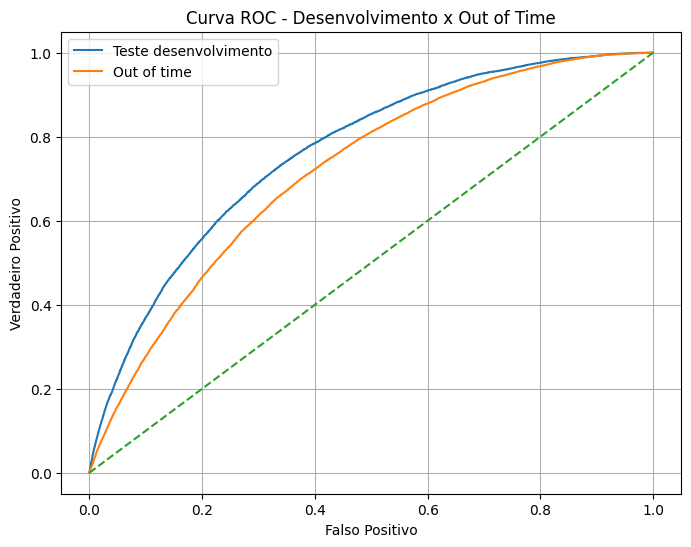

Gráfico ROC gerado.


In [18]:
# Curva ROC para desenvolvimento e OOT
fpr_test, tpr_test, _ = roc_curve(y_test, proba_test)
fpr_oot, tpr_oot, _ = roc_curve(y_oot, proba_oot)

plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, label='Teste desenvolvimento')
plt.plot(fpr_oot, tpr_oot, label='Out of time')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Curva ROC - Desenvolvimento x Out of Time')
plt.xlabel('Falso Positivo')
plt.ylabel('Verdadeiro Positivo')
plt.legend()
plt.grid(True)
plt.show()

print('Gráfico ROC gerado.')

# a - Criar um pipeline utilizando o sklearn pipeline para o preprocessamento 

## Pré processamento

### Substituição de nulos (nans)

Existe nulos na base? é dado numérico ou categórico? qual o valor de substituição? média? valor mais frequente? etc

In [19]:
# Verificar nulos
nulos = (
    X_dev
    .isna()
    .sum()
    .reset_index()
)

nulos.columns = ['variavel', 'quantidade_nulos']
nulos['percentual_nulos'] = nulos['quantidade_nulos'] / len(X_dev)
nulos = nulos.sort_values('quantidade_nulos', ascending=False)

print('Variáveis com maior quantidade de nulos:')
nulos.head(20)

Variáveis com maior quantidade de nulos:


,variavel,quantidade_nulos,percentual_nulos
9,tempo_emprego,100875,0.168125
0,sexo,0,0.000000
1,posse_de_veiculo,0,0.000000
2,posse_de_imovel,0,0.000000
3,qtd_filhos,0,0.000000
4,tipo_renda,0,0.000000
5,educacao,0,0.000000
6,estado_civil,0,0.000000
7,tipo_residencia,0,0.000000
8,idade,0,0.000000


In [20]:
# Estratégia de substituição de nulos
estrategia_nulos = pd.DataFrame({
    'variavel': variaveis_numericas + variaveis_categoricas,
    'tipo': ['numérica'] * len(variaveis_numericas) + ['categórica'] * len(variaveis_categoricas),
    'estrategia': ['mediana'] * len(variaveis_numericas) + ['mais frequente'] * len(variaveis_categoricas)
})

print('Estratégia definida para tratamento de nulos:')
estrategia_nulos.head(30)

Estratégia definida para tratamento de nulos:


,variavel,tipo,estrategia
0,qtd_filhos,numérica,mediana
1,idade,numérica,mediana
2,tempo_emprego,numérica,mediana
3,qt_pessoas_residencia,numérica,mediana
4,renda,numérica,mediana
5,sexo,categórica,mais frequente
6,posse_de_veiculo,categórica,mais frequente
7,posse_de_imovel,categórica,mais frequente
8,tipo_renda,categórica,mais frequente
9,educacao,categórica,mais frequente


### Remoção de outliers

Como identificar outlier? Substituir o outlier por algum valor? Remover a linha?

In [21]:
# Limites de outliers para variáveis numéricas
limites_outliers = X_train[variaveis_numericas].quantile([0.01, 0.99]).T
limites_outliers.columns = ['p01', 'p99']

print('Limites para tratamento de outliers:')
limites_outliers.head(20)

Limites para tratamento de outliers:


,p01,p99
qtd_filhos,0.000000,3.000000
idade,25.000000,66.000000
tempo_emprego,0.320548,31.621918
qt_pessoas_residencia,1.000000,5.000000
renda,857.357500,325105.671600


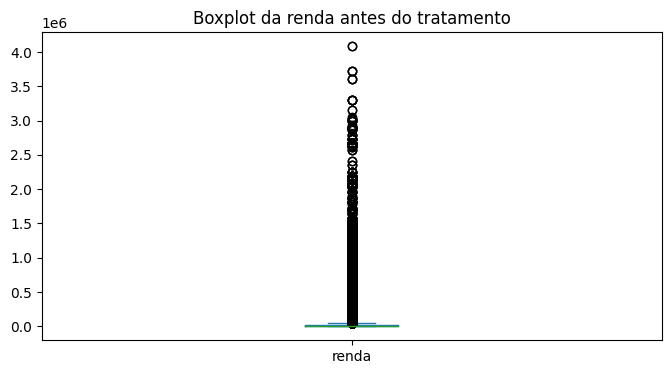

Boxplot da renda gerado.


In [22]:
# Exemplo visual antes do tratamento de outlier para renda, se a variável existir
if 'renda' in X_train.columns:
    plt.figure(figsize=(8, 4))
    X_train['renda'].plot(kind='box')
    plt.title('Boxplot da renda antes do tratamento')
    plt.show()

    print('Boxplot da renda gerado.')
else:
    print('A variável renda não foi encontrada na base.')

In [23]:
# O tratamento será aplicado dentro do pipeline usando a classe LimitadorOutliers
print('O tratamento de outliers será feito dentro do pipeline.')

O tratamento de outliers será feito dentro do pipeline.


### Seleção de variáveis

Qual tipo de técnica? Boruta? Feature importance? 

In [24]:
# Conferir variáveis selecionadas para modelagem
variaveis_modelagem = X_dev.columns.tolist()

print('Quantidade de variáveis selecionadas:', len(variaveis_modelagem))
pd.DataFrame({'variaveis_modelagem': variaveis_modelagem}).head(30)

Quantidade de variáveis selecionadas: 12


,variaveis_modelagem
0,sexo
1,posse_de_veiculo
2,posse_de_imovel
3,qtd_filhos
4,tipo_renda
5,educacao
6,estado_civil
7,tipo_residencia
8,idade
9,tempo_emprego


In [25]:
# Conferir correlação entre variáveis numéricas
correlacao_numericas = X_dev[variaveis_numericas].corr()

print('Matriz de correlação das variáveis numéricas:')
correlacao_numericas.head()

Matriz de correlação das variáveis numéricas:


,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda
qtd_filhos,1.000000,-0.369892,-0.075889,0.890439,-0.044429
idade,-0.369892,1.000000,0.330744,-0.341117,0.108172
tempo_emprego,-0.075889,0.330744,1.000000,-0.066921,0.526759
qt_pessoas_residencia,0.890439,-0.341117,-0.066921,1.000000,-0.050763
renda,-0.044429,0.108172,0.526759,-0.050763,1.000000


In [26]:
# Variáveis com maior associação linear com mau, olhando apenas numéricas
corr_mau = (
    df_dev[variaveis_numericas + ['mau']]
    .corr(numeric_only=True)['mau']
    .drop('mau')
    .sort_values(key=abs, ascending=False)
    .reset_index()
)

corr_mau.columns = ['variavel', 'correlacao_com_mau']

print('Correlação das variáveis numéricas com mau:')
corr_mau.head(20)

Correlação das variáveis numéricas com mau:


,variavel,correlacao_com_mau
0,tempo_emprego,-0.118012
1,renda,-0.061277
2,idade,-0.025322
3,qtd_filhos,0.006810
4,qt_pessoas_residencia,0.003806


### Redução de dimensionalidade (PCA)

Aplicar PCA para reduzir a dimensionalidade para 5

In [27]:
# Pré-processamento numérico simples para aplicar PCA
pipeline_pca = Pipeline(steps=[
    ('imputacao', SimpleImputer(strategy='median')),
    ('outliers', LimitadorOutliers(limite_inferior=0.01, limite_superior=0.99)),
    ('padronizacao', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42))
])

X_train_pca = pipeline_pca.fit_transform(X_train[variaveis_numericas])
X_test_pca = pipeline_pca.transform(X_test[variaveis_numericas])

print('Dimensão do treino após PCA:', X_train_pca.shape)
pd.DataFrame(X_train_pca, columns=[f'PC{i}' for i in range(1, 6)]).head()

Dimensão do treino após PCA: (420000, 5)


,PC1,PC2,PC3,PC4,PC5
0,-2.210066,0.164300,0.910948,1.158367,0.563545
1,-1.383345,-0.464469,-0.137904,-0.171881,0.545938
2,1.288228,0.157358,0.168244,-0.313163,-0.063344
3,1.721018,0.322406,-0.916737,-0.338999,-0.102358
4,-2.207927,2.264996,-0.832394,-1.547858,0.560403


In [28]:
# Variância explicada por componente
variancia_pca = pd.DataFrame({
    'componente': [f'PC{i}' for i in range(1, 6)],
    'variancia_explicada': pipeline_pca.named_steps['pca'].explained_variance_ratio_,
    'variancia_acumulada': pipeline_pca.named_steps['pca'].explained_variance_ratio_.cumsum()
})

print('Variância explicada pelos 5 componentes:')
variancia_pca.head()

Variância explicada pelos 5 componentes:


,componente,variancia_explicada,variancia_acumulada
0,PC1,0.437396,0.437396
1,PC2,0.326851,0.764247
2,PC3,0.147574,0.911821
3,PC4,0.065565,0.977386
4,PC5,0.022614,1.000000


### Criação de dummies

Aplicar o get_dummies() ou onehotencoder() para transformar colunas catégoricas do dataframe em colunas de 0 e 1. 
- sexo
- posse_de_veiculo
- posse_de_imovel
- tipo_renda
- educacao
- estado_civil
- tipo_residencia

In [29]:
# Criar dummies com pandas para visualizar o resultado
colunas_dummies = [
    'sexo',
    'posse_de_veiculo',
    'posse_de_imovel',
    'tipo_renda',
    'educacao',
    'estado_civil',
    'tipo_residencia'
]

colunas_dummies = [col for col in colunas_dummies if col in X_dev.columns]

df_dummies_exemplo = pd.get_dummies(X_dev[colunas_dummies], drop_first=True)

print('Quantidade de colunas após criação de dummies:', df_dummies_exemplo.shape[1])
df_dummies_exemplo.head()

Quantidade de colunas após criação de dummies: 20


,sexo_M,posse_de_veiculo_S,posse_de_imovel_S,tipo_renda_Bolsista,tipo_renda_Empresário,tipo_renda_Pensionista,tipo_renda_Servidor público,educacao_Médio,educacao_Pós graduação,educacao_Superior completo,educacao_Superior incompleto,estado_civil_Separado,estado_civil_Solteiro,estado_civil_União,estado_civil_Viúvo,tipo_residencia_Casa,tipo_residencia_Com os pais,tipo_residencia_Comunitário,tipo_residencia_Estúdio,tipo_residencia_Governamental
0,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False
1,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False


In [30]:
# Exemplo apenas com posse_de_veiculo
if 'posse_de_veiculo' in X_dev.columns:
    dummy_veiculo = pd.get_dummies(X_dev[['posse_de_veiculo']], drop_first=True)
    print('Dummy da variável posse_de_veiculo:')
    dummy_veiculo.head()
else:
    print('A variável posse_de_veiculo não foi encontrada na base.')

Dummy da variável posse_de_veiculo:


### Pipeline 

Crie um pipeline contendo essas funções.

preprocessamento()
- substituicao de nulos
- remoção outliers
- PCA
- Criação de dummy de pelo menos 1 variável (posse_de_veiculo)

In [52]:
# Pipeline específico solicitado na atividade

variaveis_pipeline_num = variaveis_numericas.copy()
variaveis_pipeline_cat = ['posse_de_veiculo'] if 'posse_de_veiculo' in X_dev.columns else []

try:
    encoder_pipeline = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
except TypeError:
    encoder_pipeline = OneHotEncoder(handle_unknown='ignore', drop='first', sparse=False)

preprocessamento_pipeline = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputacao', SimpleImputer(strategy='median')),
        ('outliers', LimitadorOutliers(limite_inferior=0.01, limite_superior=0.99)),
        ('padronizacao', StandardScaler())
    ]), variaveis_pipeline_num),

    ('cat', Pipeline(steps=[
        ('imputacao', SimpleImputer(strategy='most_frequent')),
        ('dummies', encoder_pipeline)
    ]), variaveis_pipeline_cat)
])

pipeline_sklearn = Pipeline(steps=[
    ('preprocessamento', preprocessamento_pipeline),
    ('pca', PCA(n_components=5, random_state=42)),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

print('Pipeline sklearn criado.')
pipeline_sklearn

Pipeline sklearn criado.


Pipeline(memory=None,
         steps=[('preprocessamento',
                 ColumnTransformer(n_jobs=None, remainder='drop',
                                   sparse_threshold=0.3,
                                   transformer_weights=None,
                                   transformers=[('num',
                                                  Pipeline(memory=None,
                                                           steps=[('imputacao',
                                                                   SimpleImputer(add_indicator=False,
                                                                                 copy=True,
                                                                                 fill_value=None,
                                                                                 keep_empty_features=False,
                                                                                 missing_values=nan,
                                                                                 strategy='median')),
                                                                  ('outliers',
                                                                   LimitadorO...
                     n_oversamples=10, power_iteration_normalizer='auto',
                     random_state=42, svd_solver='auto', tol=0.0,
                     whiten=False)),
                ('modelo',
                 LogisticRegression(C=1.0, class_weight=None, dual=False,
                                    fit_intercept=True, intercept_scaling=1,
                                    l1_ratio=None, max_iter=1000,
                                    multi_class='auto', n_jobs=None,
                                    penalty='l2', random_state=42,
                                    solver='lbfgs', tol=0.0001, verbose=0,
                                    warm_start=False))],
         verbose=False)

In [32]:
# Treinar e avaliar o pipeline
pipeline_sklearn.fit(X_train, y_train)

proba_pipeline_test = pipeline_sklearn.predict_proba(X_test)[:, 1]
pred_pipeline_test = (proba_pipeline_test >= 0.5).astype(int)

resultado_pipeline = pd.DataFrame([
    avaliar_modelo('Pipeline sklearn - teste desenvolvimento', y_test, pred_pipeline_test, proba_pipeline_test)
])

print('Resultado do pipeline sklearn:')
resultado_pipeline

Resultado do pipeline sklearn:


,base,acuracia,auc,ks,gini
0,Pipeline sklearn - teste desenvolvimento,0.938928,0.766906,0.395639,0.533812


# b - Pycaret na base de dados 

Utilize o pycaret para pre processar os dados e rodar o modelo **lightgbm**. Faça todos os passos a passos da aula e gere os gráficos finais. E o pipeline de toda a transformação.



In [33]:
df = pd.read_feather('credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


In [34]:
# Preparar amostra para o PyCaret
# A amostra reduzida ajuda a evitar lentidão em computadores com menos memória.

dataset = df.sample(50000, random_state=42) if df.shape[0] > 50000 else df.copy()

dataset.drop(['data_ref', 'index'], axis=1, inplace=True)

data = dataset.sample(frac=0.95, random_state=786)
data_unseen = dataset.drop(data.index)

data.reset_index(inplace=True, drop=True)
data_unseen.reset_index(inplace=True, drop=True)

print('Conjunto de dados para modelagem (treino e teste): ' + str(data.shape))
print('Conjunto de dados não vistos: ' + str(data_unseen.shape))

data.head()

Conjunto de dados para modelagem (treino e teste): (47500, 13)
Conjunto de dados não vistos: (2500, 13)


,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,M,S,N,0,Assalariado,Médio,Casado,Casa,45,11.106849,2.0,38003.82,False
1,F,N,N,0,Servidor público,Superior completo,Casado,Casa,60,14.353425,2.0,114305.63,False
2,M,S,N,1,Servidor público,Superior completo,Casado,Casa,35,9.791781,3.0,22011.06,False
3,M,S,N,0,Assalariado,Médio,Casado,Casa,52,10.030137,2.0,25078.07,False
4,F,N,S,0,Pensionista,Fundamental,Casado,Casa,61,NaN,2.0,11493.42,False


In [36]:
# Preparando a base para o PyCaret

dataset = df.sample(50000, random_state=42)

dataset.drop(['data_ref', 'index'], axis=1, inplace=True)

data = dataset.sample(frac=0.95, random_state=786)
data_unseen = dataset.drop(data.index)

data.reset_index(inplace=True, drop=True)
data_unseen.reset_index(inplace=True, drop=True)

print('Conjunto de dados para modelagem (treino e teste): ' + str(data.shape))
print('Conjunto de dados não vistos: ' + str(data_unseen.shape))

data.head()

Conjunto de dados para modelagem (treino e teste): (47500, 13)
Conjunto de dados não vistos: (2500, 13)


,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,M,S,N,0,Assalariado,Médio,Casado,Casa,45,11.106849,2.0,38003.82,False
1,F,N,N,0,Servidor público,Superior completo,Casado,Casa,60,14.353425,2.0,114305.63,False
2,M,S,N,1,Servidor público,Superior completo,Casado,Casa,35,9.791781,3.0,22011.06,False
3,M,S,N,0,Assalariado,Médio,Casado,Casa,52,10.030137,2.0,25078.07,False
4,F,N,S,0,Pensionista,Fundamental,Casado,Casa,61,NaN,2.0,11493.42,False


In [37]:
from pycaret.classification import *

exp_clf = setup(
    data=data,
    target='mau',
    session_id=123,
    normalize=True,
    normalize_method='zscore'
)

,Description,Value
0,Session id,123
1,Target,mau
2,Target type,Binary
3,Original data shape,"(47500, 13)"
4,Transformed data shape,"(47500, 30)"
5,Transformed train set shape,"(33250, 30)"
6,Transformed test set shape,"(14250, 30)"
7,Numeric features,5
8,Categorical features,7
9,Rows with missing values,16.8%


In [38]:
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [53]:
# Criando o modelo LightGBM

lightgbm = create_model('lightgbm', fold=5)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9206,0.7586,0.0152,0.4211,0.0294,0.0240,0.0679
1,0.9206,0.7613,0.0267,0.4516,0.0504,0.0419,0.0946
2,0.9209,0.7562,0.0267,0.4828,0.0505,0.0426,0.0991
3,0.9198,0.7616,0.0380,0.4255,0.0698,0.0576,0.1083
4,0.9200,0.7707,0.0228,0.4000,0.0432,0.0349,0.0800
Mean,0.9204,0.7617,0.0259,0.4362,0.0487,0.0402,0.0900
Std,0.0004,0.0049,0.0074,0.0285,0.0131,0.0110,0.0143


In [54]:
tuned_lightgbm = tune_model(lightgbm, optimize='AUC', fold=5)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9211,0.7738,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.9211,0.7738,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.9211,0.7637,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.9209,0.7743,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.9209,0.7867,0.0000,0.0000,0.0000,0.0000,0.0000
Mean,0.9210,0.7745,0.0000,0.0000,0.0000,0.0000,0.0000
Std,0.0001,0.0073,0.0000,0.0000,0.0000,0.0000,0.0000


Fitting 5 folds for each of 10 candidates, totalling 50 fits


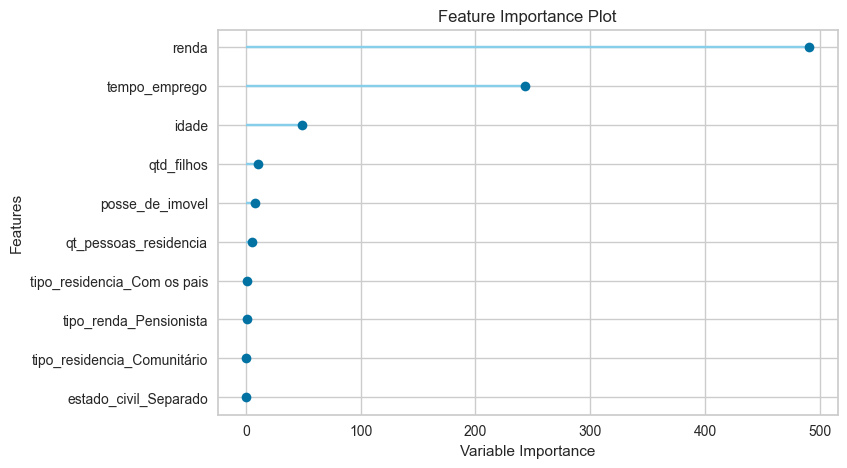

In [57]:
plot_model(tuned_lightgbm, plot='feature')

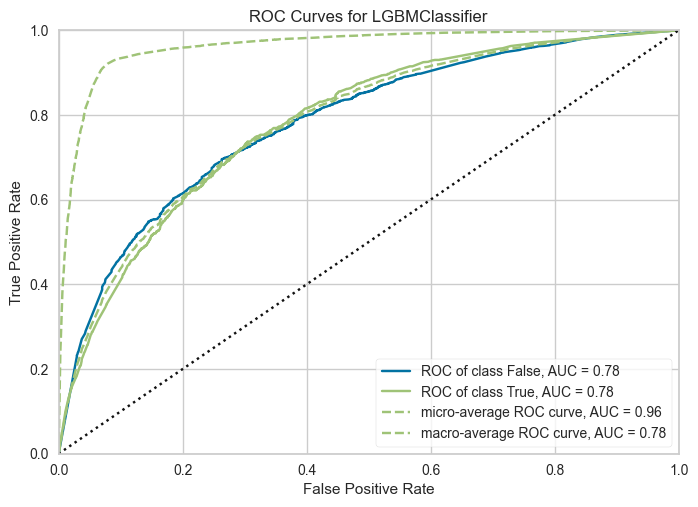

In [58]:
plot_model(tuned_lightgbm, plot='auc')

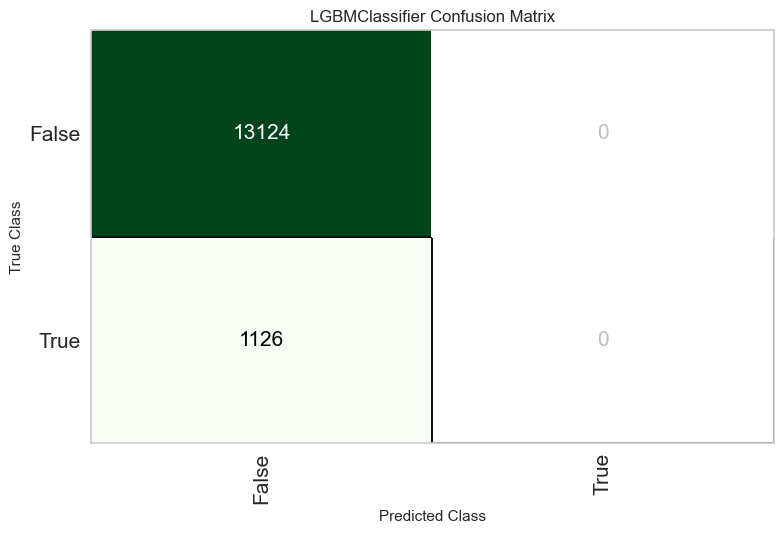

In [59]:
plot_model(tuned_lightgbm, plot='confusion_matrix')

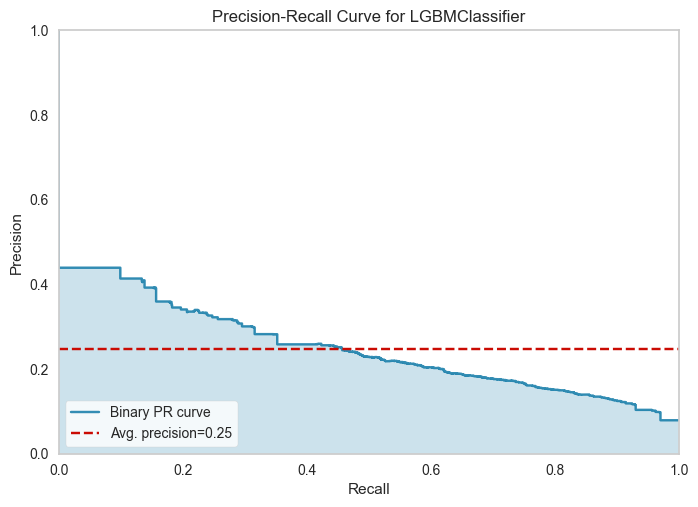

In [60]:
plot_model(tuned_lightgbm, plot='pr')

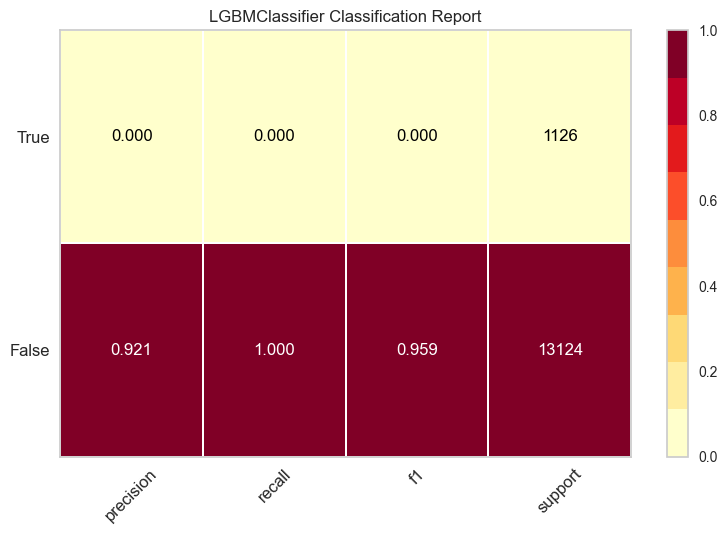

In [61]:
plot_model(tuned_lightgbm, plot='class_report')